# Import Required Libraries
Import the necessary libraries, including the dataset loader from src/dataloaders/datasets/a_thaliana_dataset.py.

In [1]:
from transformers import AutoTokenizer
from datasets import Dataset

# list of HyenaDNA pretrained models available in the hugging face hub
pretrained_models_max_length = {
    'hyenadna-tiny-1k-seqlen-hf': 1024,
        'hyenadna-small-32k-seqlen-hf': 32768,
        'hyenadna-medium-160k-seqlen-hf': 160000,
        'hyenadna-medium-450k-seqlen-hf': 450000,  # T4 up to here
        'hyenadna-large-1m-seqlen-hf': 1_000_000,
}

In [2]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

# instantiate pretrained model
pretrained_model_name = 'hyenadna-tiny-1k-seqlen-hf'
checkpoint = 'LongSafari/'+pretrained_model_name
tokenizer = AutoTokenizer.from_pretrained(checkpoint, revision="main", trust_remote_code=True)
model  = AutoModelForSequenceClassification.from_pretrained(checkpoint, revision="main", torch_dtype=torch.bfloat16, device_map="auto", trust_remote_code=True)

/home/lpedraza/.cache/pypoetry/virtualenvs/hyena-dna-mFh94ihl-py3.8/lib/python3.8/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at LongSafari/hyenadna-tiny-1k-seqlen-hf were not used when initializing HyenaDNAForSequenceClassification: ['lm_head.weight']
- This IS expected if you are initializing HyenaDNAForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HyenaDNAForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification mode

### Data loading

In [3]:
# Experiment settings:

# Define the paths to the BED and FA files
bed_file_path = 'data/A.Thaliana/Atha.RegRgn.datasets.v01/Atha_RegRgn.bed'
fa_file_path = 'data/A.Thaliana/TAIR10_mod.fna'
# Other dataset settings
use_padding = True
padding_only = True  # pad with '.' only
rc_aug = True  # reverse complement augmentation
rand_aug = False  # random extension for intergenic regions less than max_length
add_eos = False  # add end of sentence token
# Training settings
num_epochs = 10  # ~5 seems fine
max_length = 1000  # max len of sequence of dataset (of what you want)
batch_size = 64 # ~256 was used
learning_rate = 8e-5  # 6e-4 good default for Hyena
weight_decay = 0.1

In [4]:
# Import the dataset loader
from numpy import pad
from src.dataloaders.datasets.a_thaliana_dataset import a_thalinana_Dataset

# Load the dataset using the provided BED and FA files
ds_test = a_thalinana_Dataset(bed_file=bed_file_path, 
                              fasta_file=fa_file_path, 
                              split='test', 
                              max_length = max_length,
                              tokenizer = tokenizer,
                              tokenizer_name='char',
                              replace_N_token = True,
                              rand_aug = rand_aug,
                              pad_interval = use_padding,
                              pad_only = padding_only,
                              deterministic_mode = True
                              )
ds_val = a_thalinana_Dataset(bed_file=bed_file_path, 
                              fasta_file=fa_file_path, 
                              split='val', 
                              max_length = max_length,
                              tokenizer = tokenizer,
                              tokenizer_name='char',
                              replace_N_token = True,
                              rand_aug = rand_aug,
                              pad_interval = use_padding,
                              pad_only = padding_only,
                              deterministic_mode = True
                              )
ds_train = a_thalinana_Dataset(bed_file=bed_file_path, 
                              fasta_file=fa_file_path, 
                              split='train', 
                              max_length = max_length,
                              tokenizer = tokenizer,
                              tokenizer_name='char',
                              replace_N_token = True,
                              rand_aug = rand_aug,
                              pad_interval = use_padding,
                              pad_only = padding_only,
                              deterministic_mode = True
                              )

print(f"Train dataset shape:[{len(ds_train)},{len(ds_train[0]['input_ids'])}]")
print(f"Train labels shape:[{len(ds_train)},{len(ds_train[0]['labels'])}]")  
print(f"Evaluation dataset shape:[{len(ds_val)},{len(ds_val[0]['input_ids'])}]")
print(f"Evaluation labels shape:[{len(ds_val)},{len(ds_val[0]['labels'])}]")
print(f"Test dataset shape:[{len(ds_test)},{len(ds_test[0]['input_ids'])}]")
print(f"Test labels shape:[{len(ds_test)},{len(ds_test[0]['labels'])}]")

Train dataset shape:[27884,1000]
Train labels shape:[27884,1]
Evaluation dataset shape:[3468,1000]
Evaluation labels shape:[3468,1]
Test dataset shape:[3430,1000]
Test labels shape:[3430,1]


In [28]:
#checking padding
for i in range(5):
    ids = ds_train[i]["input_ids"]
    seq = tokenizer.decode(ids, skip_special_tokens=False)
    seq = seq.replace("[UNK]", ".")
    print(seq)

...............................................................................................................................................................................................................................................................................................................AAATCTTCTTGTGAGTCACTCTTCTTCATGACTTGGATCTCCTCCATAGAATCTTTCGGTGATCGAGAGCGATTCACTATAGAAAGTCTCTTCAAATTTCACCCAAATGGCTGTTTGATCTTGGTCTCAAACTCATTTGACTGTGACAGAGGAACCTTAATCTTGAAACCCTTTACAGATAAAGGGCTTAAAGTGCTTCCAATCAAACCTGATTTTGCTTACATCTTCAAAGATACATCAGCAGAGAAATGGTTTGAAAGATTGAAGAAAGGAACACTCAGTCCAGGAGTGATTCCATTAGAGCAAAACCTCTCAAACCTTCTAAGATTAGTCCTGCTCTACAAATACGGCGGAATCTACTTAGACACAGACGTTATAATCCTCAAATCTCTCA...............................................................................................................................................................................................................................................................................................................

In [29]:
len(seq)

1000

### Trianing

In [5]:
# filter out warnings
import warnings
warnings.filterwarnings("ignore")

# disable wandb
import os 
os.environ["WANDB_DISABLED"] = "true"

In [6]:
from torch.utils.data import Subset

train_len = min(64*500,len(ds_train))
val_len = min(100,len(ds_val))

subset_train = Subset(ds_train, range(train_len)) # take a subset of the dataset

subset_val = Subset(ds_val, range(val_len)) # take a subset of the dataset

In [7]:
from transformers import TrainerCallback, TrainingArguments, Trainer

# Define el callback for logging the loss
class LossLoggerCallback(TrainerCallback):
    def __init__(self):
        self.train_loss = []
        self.eval_loss = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            if 'loss' in logs:
                self.train_loss.append(logs['loss'])
            if 'eval_loss' in logs:
                self.eval_loss.append(logs['eval_loss'])

# Define el callback
loss_logger = LossLoggerCallback()

# Define los argumentos de entrenamiento
args = {
    "output_dir": "tmp",
    "num_train_epochs": num_epochs,
    "per_device_train_batch_size": batch_size,
    "per_device_eval_batch_size": batch_size,
    "evaluation_strategy": "epoch", # eval after each epoch
    "gradient_accumulation_steps": 4, # for larger batch sizes
    #"gradient_checkpointing": True, # 'HyenaDNAForSequenceClassification' object has no attribute '_set_gradient_checkpointing'
    "learning_rate": learning_rate,
    "logging_strategy": "epoch",
    "save_strategy": "epoch",
}
training_args = TrainingArguments(**args)

# Crea el Trainer y añade el callback
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=subset_train,
    eval_dataset=subset_val,  # Asegúrate de incluir el dataset de evaluación
    callbacks=[loss_logger]
)


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [8]:
# Entrena el modelo
result = trainer.train()

***** Running training *****
  Num examples = 27884
  Num Epochs = 10
  Instantaneous batch size per device = 64
  Total train batch size (w. parallel, distributed & accumulation) = 256
  Gradient Accumulation steps = 4
  Total optimization steps = 1090
  Number of trainable parameters = 436352


  0%|          | 0/1090 [00:00<?, ?it/s]

***** Running Evaluation *****
  Num examples = 100
  Batch size = 64


{'loss': 0.6548, 'learning_rate': 7.2e-05, 'epoch': 1.0}


  0%|          | 0/2 [00:00<?, ?it/s]

...

***** Running Evaluation *****
  Num examples = 100
  Batch size = 64


{'loss': 0.4048, 'learning_rate': 0.0, 'epoch': 10.0}


  0%|          | 0/2 [00:00<?, ?it/s]

Saving model checkpoint to tmp/checkpoint-1090
Configuration saved in tmp/checkpoint-1090/config.json
Model weights saved in tmp/checkpoint-1090/pytorch_model.bin


Training completed. Do not forget to share your model on huggingface.co/models =)




{'eval_loss': 0.408203125, 'eval_runtime': 0.29, 'eval_samples_per_second': 344.779, 'eval_steps_per_second': 6.896, 'epoch': 10.0}
{'train_runtime': 963.4877, 'train_samples_per_second': 289.407, 'train_steps_per_second': 1.131, 'train_loss': 0.4628995842889908, 'epoch': 10.0}


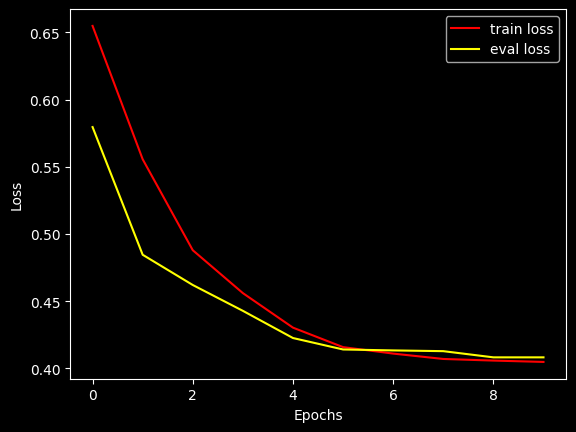

In [9]:
# Plot the loss
import matplotlib.pyplot as plt

plt.plot(loss_logger.train_loss, label="train loss", color='red')
plt.plot(loss_logger.eval_loss, label="eval loss", color='yellow')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Evaluate the model on validation data

In [10]:
import numpy as np
import torch
from torch.utils.data import DataLoader

# Fijar semillas para reproducibilidad
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)  # Puedes usar cualquier número como semilla

# Verifica si hay una GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# Define el tamaño del batch
batch_size = 32  # Ajusta este valor según la memoria disponible

# Crea un DataLoader para procesar los datos en batches
dataloader = DataLoader(ds_val, batch_size=batch_size, shuffle=False)

# Inicializa variables para calcular la pérdida y precisión acumuladas
total_loss = 0.0
correct = 0
total_samples = 0
pred, target = [], []


# Establece el modelo en modo de evaluación
model.eval()

# Desactiva el cálculo de gradientes
with torch.no_grad():
    for batch in dataloader:
        # Extrae los tensores de los diccionarios en el batch
        data_batch = batch['input_ids'].to(device)
        target_batch = batch['labels'].to(device)

        # Realiza la inferencia
        output = model(data_batch)

        # Calcula la pérdida
        loss = torch.nn.functional.cross_entropy(output["logits"], target_batch.squeeze())
        total_loss += loss.item() * len(data_batch)

        # Obtiene la clase predicha
        pred_batch = output["logits"].argmax(dim=1, keepdim=True)

        # Calcula el número de predicciones correctas
        correct += pred_batch.eq(target_batch.view_as(pred_batch)).sum().item()
        total_samples += len(target_batch)

        # Guarda las predicciones y etiquetas
        pred.extend(pred_batch.cpu().numpy())
        target.extend(target_batch.cpu().numpy())
        
# convierte a numpy array
pred = np.array(pred)
target = np.array(target)

# Calcula la pérdida y precisión promedio
average_loss = total_loss / total_samples
accuracy = 100. * correct / total_samples

print(f'Loss: {average_loss:.4f}, Accuracy: {accuracy:.2f}%')


Usando dispositivo: cuda
Loss: 0.4115, Accuracy: 81.72%


In [11]:
ds_val.label_dict

{'non_regulatory': 0, 'regulatory': 1}

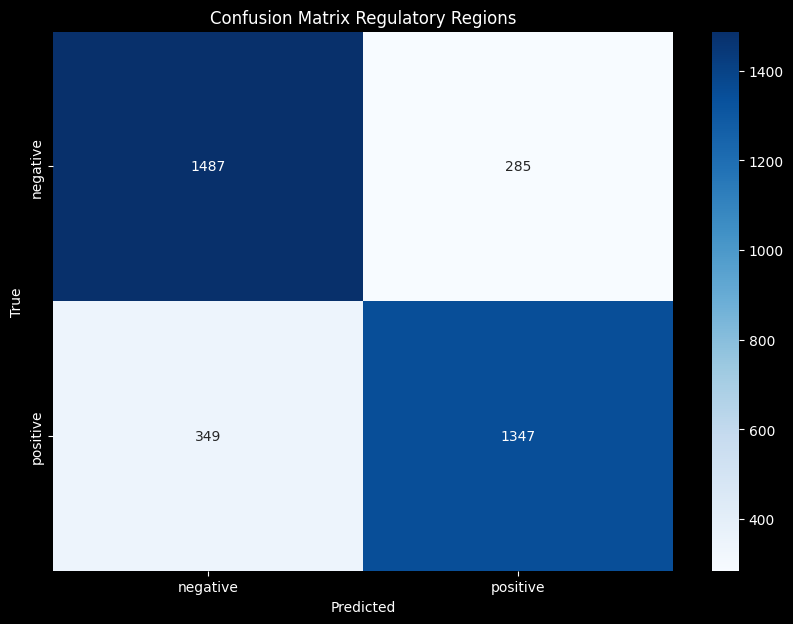

In [12]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(target, pred)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Regulatory Regions')
plt.show()